## Project 01 - When the Fed Turns Hawkish

In [1]:
pip install pandas numpy matplotlib fredapi yfinance statsmodels scipy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
from dotenv import load_dotenv
import os
load_dotenv() 
FRED_API_KEY = os.getenv("API_KEY")

# First part of the research. 

# STEP 1 : SETUP: imports and configuration

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import yfinance as yf
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

fred = Fred(api_key=FRED_API_KEY)
print("Environment ready.")

Environment ready.


# STEP 2 :  FRED DATA (FRED)

In [80]:
# Step 1: Get 2Y Treasury FIRST — this becomes our master daily calendar
dgs2 = fred.get_series('DGS2')
dgs2.index = pd.to_datetime(dgs2.index).normalize()
dgs2 = dgs2.dropna()

print(f"2Y Treasury: {len(dgs2)} observations, "
      f"{dgs2.index.min().date()} to {dgs2.index.max().date()}")

# Step 2: Get other DAILY series and align them to the 2Y calendar
daily_series_codes = {
    'DGS10':        '10Y_Treasury',
    'DFII10':       '10Y_Real_Yield',
    'DFF':          'Fed_Funds_Rate',
    'VIXCLS':       'VIX',
    'BAMLH0A0HYM2': 'HY_Spread',
}

fred_df = pd.DataFrame({'2Y_Treasury': dgs2})

for code, name in daily_series_codes.items():
    s = fred.get_series(code)
    s.index = pd.to_datetime(s.index).normalize()
    # Reindex to our master calendar, then forward-fill weekend/holiday gaps
    fred_df[name] = s.reindex(fred_df.index).ffill()

print(f"\nfred_df shape: {fred_df.shape}")

# Step 3: CPI is MONTHLY — keep it separate, we'll attach it via .asof() later
# (mixing monthly + daily directly into one DataFrame caused index corruption before)
cpi_monthly = fred.get_series('CPIAUCSL')
cpi_monthly.index = pd.to_datetime(cpi_monthly.index).normalize()
cpi_yoy = cpi_monthly.pct_change(12) * 100  # year-over-year inflation rate

print(f"CPI (monthly, kept separate): {len(cpi_monthly)} observations")
fred_df.tail()

2Y Treasury: 12562 observations, 1976-06-01 to 2026-09-03

fred_df shape: (12562, 6)
CPI (monthly, kept separate): 955 observations


,2Y_Treasury,10Y_Treasury,10Y_Real_Yield,Fed_Funds_Rate,VIX,HY_Spread
2026-08-28,4.34,4.73,2.42,3.63,14.43,2.60
2026-08-31,4.34,4.75,2.44,3.63,14.92,2.63
2026-09-01,4.39,4.79,2.44,3.63,16.34,2.65
2026-09-02,4.39,4.79,2.45,3.63,15.20,2.66
2026-09-03,4.34,4.77,2.42,3.63,14.32,2.65


# STEP 3 : FOMC MEETING DATES (1994 - 2024)

In [92]:
# (1994-2024, including previously missing 2007-2014)
FOMC_DATES_RAW = [
    # 1994-1995 ("bond massacre" hiking cycle)
    '1994-02-04', '1994-03-22', '1994-04-18', '1994-05-17',
    '1994-08-16', '1994-11-15', '1995-02-01', '1995-07-06',
    # 1999-2000
    '1999-06-30', '1999-08-24', '1999-11-16', '2000-02-02',
    '2000-03-21', '2000-05-16',
    # 2004-2006 ("measured pace" hiking cycle)
    '2004-06-30', '2004-08-10', '2004-09-21', '2004-11-10', '2004-12-14',
    '2005-02-02', '2005-03-22', '2005-05-03', '2005-06-30', '2005-08-09',
    '2005-09-20', '2005-11-01', '2005-12-13',
    '2006-01-31', '2006-03-28', '2006-05-10', '2006-06-29',
    # 2007-2014 (financial crisis + QE era — previously missing!)
    '2007-09-18', '2007-10-31', '2007-12-11',
    '2008-01-30', '2008-03-18', '2008-04-30', '2008-06-25',
    '2008-08-05', '2008-09-16', '2008-10-29', '2008-12-16',
    '2009-01-28', '2009-03-18', '2009-04-29', '2009-06-24',
    '2009-08-12', '2009-09-23', '2009-11-04', '2009-12-16',
    '2010-01-27', '2010-03-16', '2010-04-28', '2010-06-23',
    '2010-08-10', '2010-09-21', '2010-11-03', '2010-12-14',
    '2011-01-26', '2011-03-15', '2011-04-27', '2011-06-22',
    '2011-08-09', '2011-09-21', '2011-11-02', '2011-12-13',
    '2012-01-25', '2012-03-13', '2012-04-25', '2012-06-20',
    '2012-08-01', '2012-09-13', '2012-10-24', '2012-12-12',
    '2013-01-30', '2013-03-20', '2013-05-01', '2013-06-19',
    '2013-07-31', '2013-09-18', '2013-10-30', '2013-12-18',
    '2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18',
    '2014-07-30', '2014-09-17', '2014-10-29', '2014-12-17',
    # 2015-2019
    '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17',
    '2015-07-29', '2015-09-17', '2015-10-28', '2015-12-16',
    '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15',
    '2016-07-27', '2016-09-21', '2016-11-02', '2016-12-14',
    '2017-02-01', '2017-03-15', '2017-05-03', '2017-06-14',
    '2017-07-26', '2017-09-20', '2017-11-01', '2017-12-13',
    '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13',
    '2018-08-01', '2018-09-26', '2018-11-08', '2018-12-19',
    '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19',
    '2019-07-31', '2019-09-18', '2019-10-30', '2019-12-11',
    # 2020-2024 (COVID + inflation shock cycle)
    '2020-01-29', '2020-03-03', '2020-03-15', '2020-04-29',
    '2020-06-10', '2020-07-29', '2020-09-16', '2020-11-05', '2020-12-16',
    '2021-01-27', '2021-03-17', '2021-04-28', '2021-06-16',
    '2021-07-28', '2021-09-22', '2021-11-03', '2021-12-15',
    '2022-01-26', '2022-03-16', '2022-05-04', '2022-06-15',
    '2022-07-27', '2022-09-21', '2022-11-02', '2022-12-14',
    '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14',
    '2023-07-26', '2023-09-20', '2023-11-01', '2023-12-13',
    '2024-01-31', '2024-03-20', '2024-05-01', '2024-06-12',
    '2024-07-31', '2024-09-18', '2024-11-07', '2024-12-18',
]

FOMC_DATES = pd.to_datetime(sorted(set(FOMC_DATES_RAW))).normalize()
print(f"Total FOMC meetings loaded: {len(FOMC_DATES)}")

# Verify these dates exist in our FRED calendar
matches = FOMC_DATES.isin(fred_df.index)
print(f"Matching dates in fred_df: {matches.sum()} out of {len(FOMC_DATES)}")

Total FOMC meetings loaded: 171
Matching dates in fred_df: 170 out of 171


# STEP 4: Market Data Collection (yfinance)

In [82]:
tickers = {
    'SP500':    '^GSPC',
    'Nasdaq':   '^IXIC',
    'DXY':      'DX-Y.NYB',
    'Gold':     'GC=F',
    'BTC':      'BTC-USD',
    'Oil':      'CL=F',
    'HYG':      'HYG',
}

market_data_clean = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start='1994-01-01', progress=False)
    series = df['Close']
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    series.index = pd.to_datetime(series.index).normalize()
    market_data_clean[name] = series.rename(name)
    print(f"✓ {name}: {len(series)} rows, {series.index.min().date()} to {series.index.max().date()}")

prices_df = pd.concat(market_data_clean.values(), axis=1)
prices_df.columns = market_data_clean.keys()
print(f"\nprices_df shape: {prices_df.shape}")

✓ SP500: 8224 rows, 1994-01-03 to 2026-09-04
✓ Nasdaq: 8224 rows, 1994-01-03 to 2026-09-04
✓ DXY: 8301 rows, 1994-01-03 to 2026-09-04
✓ Gold: 6528 rows, 2000-08-30 to 2026-09-04
✓ BTC: 4372 rows, 2014-09-17 to 2026-09-05
✓ Oil: 6537 rows, 2000-08-23 to 2026-09-04
✓ HYG: 4883 rows, 2007-04-11 to 2026-09-04

prices_df shape: (9664, 7)


# Step 5: Alignment & Returns Calculation

In [84]:
# Reindex market prices to our master FRED calendar, forward-fill gaps
prices_aligned = prices_df.reindex(fred_df.index).ffill()
prices_aligned = prices_aligned.dropna(how='all')

# Log returns: ln(price_today / price_yesterday)
returns_df = np.log(prices_aligned / prices_aligned.shift(1))
returns_df = returns_df.dropna(how='all')

print(f"returns_df shape: {returns_df.shape}")
print(f"Date range: {returns_df.index.min().date()} to {returns_df.index.max().date()}")

matches_returns = FOMC_DATES.isin(returns_df.index)
print(f"FOMC dates matching returns_df: {matches_returns.sum()} out of {len(FOMC_DATES)}")

returns_df shape: (8173, 7)
Date range: 1994-01-04 to 2026-09-03
FOMC dates matching returns_df: 170 out of 171


# STEP 6 : BUILD CONTINUOUS SHOCK PANEL

In [87]:
def build_shock_panel(yield_2y, fomc_dates, returns_df, forward_windows=[1, 5, 20, 60]):
    """
    For each FOMC date:
    1. Compute the change in 2Y yield on that day (our 'shock' magnitude, in bps)
    2. Compute forward cumulative returns for every asset over each horizon
    
    We look up positions SEPARATELY in yield_2y.index and returns_df.index,
    because these two series start on different dates. Reusing one position 
    across both would silently reference the wrong calendar dates.
    """
    panel_rows = []
    skipped = 0
    
    for date in fomc_dates:
        # The date must exist in BOTH series
        if date not in yield_2y.index or date not in returns_df.index:
            skipped += 1
            continue
        
        # --- Position within yield_2y's own index ---
        yidx = yield_2y.index.get_loc(date)
        if isinstance(yidx, slice) or hasattr(yidx, '__len__') or yidx == 0:
            skipped += 1
            continue
        
        yield_change_bps = (yield_2y.iloc[yidx] - yield_2y.iloc[yidx - 1]) * 100
        if pd.isna(yield_change_bps):
            skipped += 1
            continue
        
        # --- Position within returns_df's own index (separate lookup!) ---
        ridx = returns_df.index.get_loc(date)
        if isinstance(ridx, slice) or hasattr(ridx, '__len__'):
            skipped += 1
            continue
        
        row = {'date': date, 'yield_shock_bps': yield_change_bps}
        
        for asset in returns_df.columns:
            for w in forward_windows:
                if ridx + w < len(returns_df):
                    # min_count ensures NaN (not fake 0) if asset didn't exist yet
                    # (e.g., BTC before 2014, HYG before 2007)
                    fwd_ret = returns_df[asset].iloc[ridx : ridx + w + 1].sum(min_count=w + 1)
                    row[f'{asset}_ret_{w}d'] = fwd_ret
        
        panel_rows.append(row)
    
    print(f"Processed {len(fomc_dates)} FOMC dates: {len(panel_rows)} kept, {skipped} skipped")
    return pd.DataFrame(panel_rows)


shock_panel = build_shock_panel(
    yield_2y=fred_df['2Y_Treasury'],
    fomc_dates=FOMC_DATES,
    returns_df=returns_df,
    forward_windows=[1, 5, 20, 60]
)

print(f"\nFinal shock_panel shape: {shock_panel.shape}")
shock_panel.head()

Processed 171 FOMC dates: 170 kept, 1 skipped

Final shock_panel shape: (170, 30)


,date,yield_shock_bps,SP500_ret_1d,SP500_ret_5d,SP500_ret_20d,SP500_ret_60d,Nasdaq_ret_1d,Nasdaq_ret_5d,Nasdaq_ret_20d,Nasdaq_ret_60d,DXY_ret_1d,DXY_ret_5d,DXY_ret_20d,DXY_ret_60d,Gold_ret_1d,Gold_ret_5d,Gold_ret_20d,Gold_ret_60d,BTC_ret_1d,BTC_ret_5d,BTC_ret_20d,BTC_ret_60d,Oil_ret_1d,Oil_ret_5d,Oil_ret_20d,Oil_ret_60d,HYG_ret_1d,HYG_ret_5d,HYG_ret_20d,HYG_ret_60d
0,1994-02-04,14.0,-1.879376e-02,-0.022149,-0.029128,-0.062202,-0.023578,-0.020771,-0.003440,-0.074790,0.008000,0.008103,-0.006698,-0.036542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-03-22,-6.0,9.215718e-17,-0.034878,-0.058402,-0.021770,0.000263,-0.054129,-0.122296,-0.089077,-0.003182,-0.007335,-0.004458,-0.037223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-04-18,19.0,-8.191566e-03,0.014529,0.007124,0.016074,-0.020989,0.003880,-0.022856,-0.008844,-0.004753,-0.013793,-0.016896,-0.070386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-05-17,-15.0,2.048662e-02,0.022952,0.035624,0.031861,0.013935,0.027105,0.033061,0.022624,-0.009789,-0.007198,-0.017275,-0.047122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1994-08-16,-5.0,8.506101e-03,0.007086,0.016279,0.006785,0.013243,0.020381,0.047588,0.042069,0.000225,-0.013133,-0.012222,-0.020109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### For each FOMC date, we record (a) how much the 2Y Treasury yield moved on that day (this is our continuous "shock" - the bigger the move, the bigger the surprise for the market) 
### and (b) how all assets performed over the following 1/5/20/60 days.

# SANITY CHECK: distribution of shock magnitudes

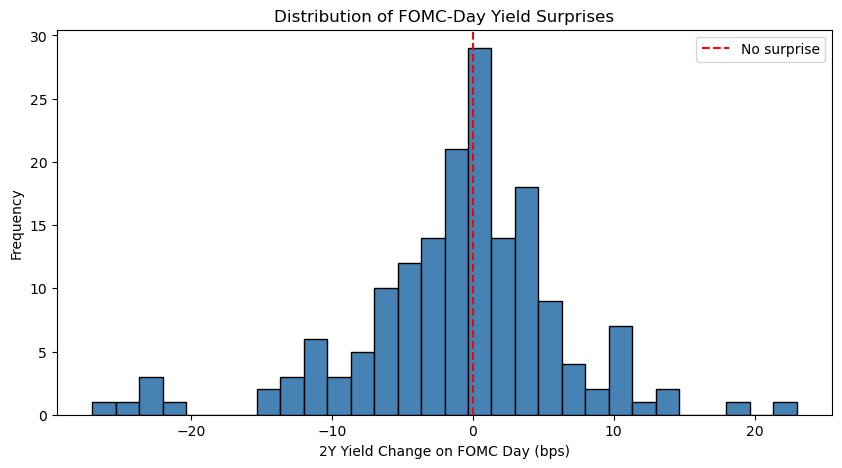

count    170.000000
mean      -1.094118
std        7.460545
min      -27.000000
25%       -4.000000
50%        0.000000
75%        3.000000
max       23.000000
Name: yield_shock_bps, dtype: float64


In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(shock_panel['yield_shock_bps'], bins=30, color='steelblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', label='No surprise')
ax.set_xlabel('2Y Yield Change on FOMC Day (bps)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of FOMC-Day Yield Surprises')
ax.legend()
plt.show()

print(shock_panel['yield_shock_bps'].describe())

# STEP 6: REGRESSION: Asset Return ~ Yield Shock Magnitude

In [ ]:
def run_shock_regression(panel_df, asset_col, maxlags=3):
    """
    OLS regression: Asset_Return = alpha + beta * Yield_Shock_bps + error
    
    beta = sensitivity of the asset to a 1bp hawkish surprise.
    HAC (Newey-West) standard errors correct for autocorrelation that arises
    because forward-return windows from consecutive FOMC meetings can overlap.
    """
    df = panel_df[['yield_shock_bps', asset_col]].dropna()
    if len(df) < 10:
        return None
    
    X = sm.add_constant(df['yield_shock_bps'])
    y = df[asset_col]
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    return model


assets = ['SP500', 'Nasdaq', 'DXY', 'Gold', 'BTC', 'Oil', 'HYG']
horizons = [1, 5, 20, 60]

regression_summary = []
for asset in assets:
    for w in horizons:
        col = f'{asset}_ret_{w}d'
        if col not in shock_panel.columns:
            continue
        model = run_shock_regression(shock_panel, col)
        if model is None:
            continue
        regression_summary.append({
            'asset': asset,
            'horizon': f'{w}d',
            'beta': model.params['yield_shock_bps'],
            'p_value': model.pvalues['yield_shock_bps'],
            'r_squared': model.rsquared,
            'n_obs': int(model.nobs)
        })

regression_df = pd.DataFrame(regression_summary)
print(regression_df.round(4))

# # STEP 7. VISUALIZATION: beta heatmap across assets and horizons

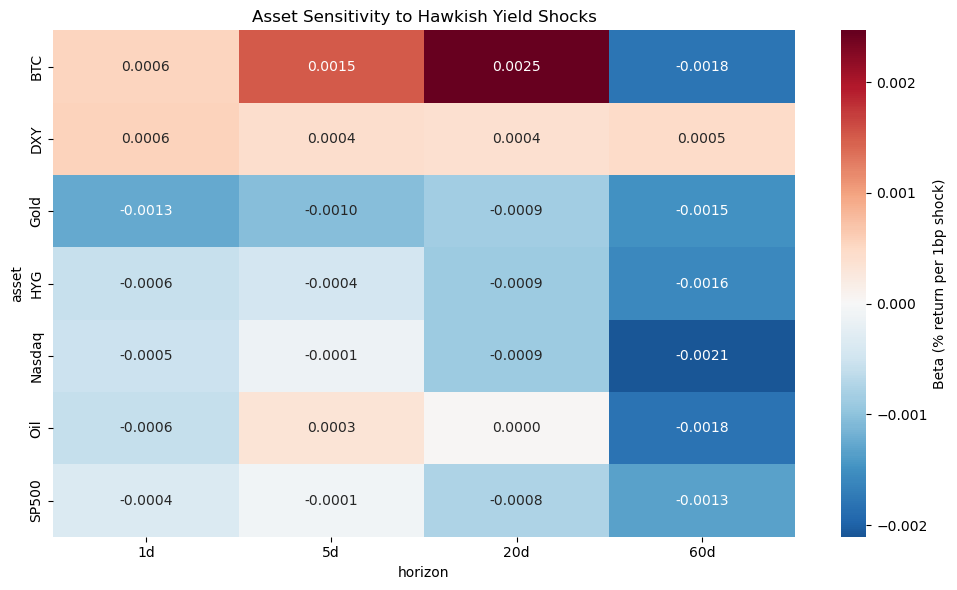

In [90]:
pivot_beta = regression_df.pivot(index='asset', columns='horizon', values='beta')
col_order = ['1d', '5d', '20d', '60d']
pivot_beta = pivot_beta[col_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_beta, annot=True, fmt='.4f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Beta (% return per 1bp shock)'})
ax.set_title('Asset Sensitivity to Hawkish Yield Shocks')
plt.tight_layout()
plt.savefig('outputs/figures/beta_heatmap.png', dpi=150)
plt.show()

# FINAL SUMMARY TABLE

In [94]:
final_20d = regression_df[regression_df['horizon'] == '20d'].sort_values('beta')
print("=== FINAL SUMMARY: 20-Day Horizon ===")
print(final_20d[['asset', 'beta', 'p_value', 'n_obs']].round(4))

=== FINAL SUMMARY: 20-Day Horizon ===
     asset    beta  p_value  n_obs
6   Nasdaq -0.0009   0.1940    170
26     HYG -0.0009   0.2041    139
14    Gold -0.0009   0.1852    156
2    SP500 -0.0008   0.2005    170
22     Oil  0.0000   0.9902    156
10     DXY  0.0004   0.0401    170
18     BTC  0.0025   0.3316     82


## All the conclusions are stated in README section. Please, follow back my fed - hawkish- repricing GitHub repository for that. 